c:\Users\sreeh\miniconda3\envs\your_env_name\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Hybrid Model Initialized.

Epoch 1/30
TRAIN Loss: 0.5744 Acc: 0.7835
VAL Loss: 0.5349 Acc: 0.7803

Epoch 2/30
TRAIN Loss: 0.2453 Acc: 0.9166
VAL Loss: 0.3328 Acc: 0.8834

Epoch 3/30
TRAIN Loss: 0.1390 Acc: 0.9523
VAL Loss: 0.3974 Acc: 0.8610

Epoch 4/30
TRAIN Loss: 0.0968 Acc: 0.9666
VAL Loss: 0.5034 Acc: 0.8879

Epoch 5/30
TRAIN Loss: 0.0880 Acc: 0.9707
VAL Loss: 0.4744 Acc: 0.8700

Epoch 6/30
TRAIN Loss: 0.0641 Acc: 0.9809
VAL Loss: 0.5008 Acc: 0.8700

Epoch 7/30
TRAIN Loss: 0.0454 Acc: 0.9860
VAL Loss: 0.3540 Acc: 0.9013

Epoch 8/30
TRAIN Loss: 0.0308 Acc: 0.9907
VAL Loss: 0.4968 Acc: 0.8655

Epoch 9/30
TRAIN Loss: 0.0267 Acc: 0.9926
VAL Loss: 0.4798 Acc: 0.8879

Epoch 10/30
TRAIN Loss: 0.0252 Acc: 0.9923
VAL Loss: 0.4156 Acc: 0.8969

Epoch 11/30
TRAIN Loss: 0.0560 Acc: 0.9818
VAL Loss: 0.3735 Acc: 0.9103

Epoch 12/30
TRAIN Loss: 0.0201 Acc: 0.9929
VAL Loss: 0.3084 Acc: 0.9193

Epoch 13/30
TRAIN Loss: 0.0197 Acc: 0.9938
VAL Loss: 0.5013 Acc: 0.8655

Epoch 14/30
TR

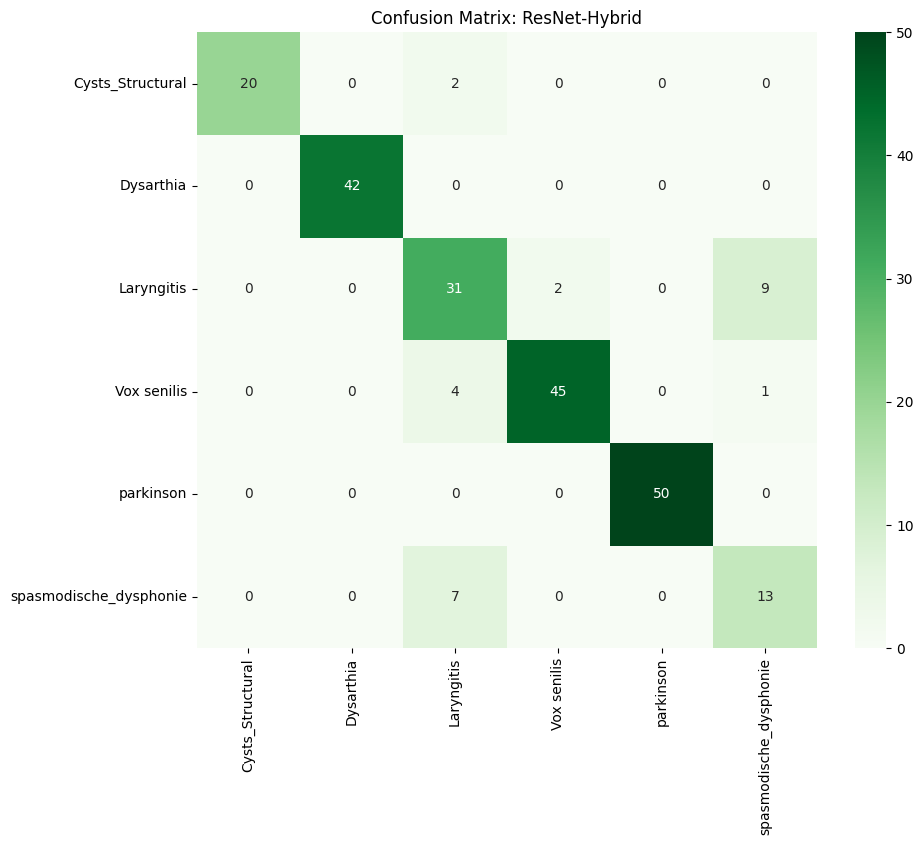

In [1]:
# --- IMPORTS ---
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader, Dataset
import copy
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# --- CONFIGURATION ---
BATCH_SIZE = 32
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# --- 1. DATA LOADING (Same as before) ---
class MemoryCachedDataset(Dataset):
    def __init__(self, cache_path):
        self.data = torch.load(cache_path)
        self.samples = self.data['samples']
        self.classes = self.data['classes']
        self.class_to_idx = self.data['class_to_idx']
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx): return self.samples[idx]

train_dataset = MemoryCachedDataset("train_cache.pt")
val_dataset = MemoryCachedDataset("val_cache.pt")
test_dataset = MemoryCachedDataset("test_cache.pt")
class_names = train_dataset.classes
num_classes = len(class_names)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- 2. THE HYBRID MODEL ARCHITECTURE ---

class ResNetDiETHybrid(nn.Module):
    def __init__(self, num_classes, embed_dim=256, num_heads=4, num_layers=4):
        super(ResNetDiETHybrid, self).__init__()
        
        # A. CNN Backbone (ResNet-34)
        # We strip the final FC and AvgPool layers
        resnet = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2]) 
        
        # ResNet34 outputs 512 channels. We project this to 'embed_dim' for the Transformer
        self.projection = nn.Conv2d(512, embed_dim, kernel_size=1)
        
        # B. Transformer Encoder
        # We treat the 7x7 spatial grid as a sequence of 49 tokens
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, dim_feedforward=512, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # C. Classification Head
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim)) # Learnable class token
        self.fc = nn.Linear(embed_dim, num_classes)
        
    def forward(self, x):
        # 1. Extract features with CNN
        # Input: (B, 3, 224, 224) -> Output: (B, 512, 7, 7)
        features = self.backbone(x)
        
        # 2. Project to Embedding Dimension
        # Output: (B, embed_dim, 7, 7)
        features = self.projection(features)
        
        # 3. Flatten and Permute for Transformer
        # (B, embed_dim, 7, 7) -> (B, embed_dim, 49) -> (B, 49, embed_dim)
        B, C, H, W = features.shape
        features = features.flatten(2).transpose(1, 2)
        
        # 4. Add Class Token
        cls_tokens = self.cls_token.expand(B, -1, -1)
        # (B, 50, embed_dim)
        tokens = torch.cat((cls_tokens, features), dim=1)
        
        # 5. Transformer Reasoning
        out = self.transformer(tokens)
        
        # 6. Classification (Use only the Class Token output)
        cls_out = out[:, 0, :]
        return self.fc(cls_out)

# Initialize Model
model = ResNetDiETHybrid(num_classes=num_classes).to(DEVICE)
print("Hybrid Model Initialized.")

# --- 3. TRAINING SETUP ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# --- 4. TRAINING LOOP ---
def train_hybrid(model, train_loader, val_loader, num_epochs=10):
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                loader = train_loader
            else:
                model.eval()
                loader = val_loader
                
            running_loss = 0.0
            corrects = 0
            
            for inputs, labels in loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                
                optimizer.zero_grad()
                
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)
                    
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                
                running_loss += loss.item() * inputs.size(0)
                corrects += torch.sum(preds == labels.data)
            
            epoch_loss = running_loss / len(loader.dataset)
            epoch_acc = corrects.double() / len(loader.dataset)
            
            print(f"{phase.upper()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")
            
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(model.state_dict(), "best_hybrid_model.pth")
        
        scheduler.step()

    print(f"Best Val Acc: {best_acc:.4f}")
    model.load_state_dict(best_model_wts)
    return model

# Run Training
trained_model = train_hybrid(model, train_loader, val_loader, num_epochs=NUM_EPOCHS)

# --- 5. EVALUATION ---
print("\n--- Final Evaluation ---")
trained_model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = trained_model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Greens')
plt.title("Confusion Matrix: ResNet-Hybrid")
plt.show()